# Tickets de Soporte Polaris — Dataset Sintético v2 · EDA (español)

**~24.000 tickets de soporte sintéticos** para *Polaris*, un SaaS de analítica
multicanal ficticio. Generados con un pipeline (catálogo de escenarios → sampler →
LLM), y encima una **capa temporal de eventos**: **caídas de servicio** (outages,
picos agudos) y **lanzamientos** de conectores (olas graduales), repartidos entre
**enero 2024 y junio 2026**.

Este notebook verifica que el dataset tiene una *firma temporal* realista — no solo
etiquetas balanceadas, sino el agrupamiento y la estacionalidad que muestra una cola
de soporte real — que es lo que lo hace útil para triage, deflexión con RAG **y**
series de tiempo (pronóstico de volumen, detección de anomalías).

> **Nota:** versión en español para estudio. El artefacto de portafolio es el
> notebook en inglés (`eda_v2.ipynb`).

In [1]:
import json, sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
sys.path.insert(0, "..")
from src.sampler import aligned_category  # la categoría 'correcta' del picklist por (topic, type)

pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
ACCENT, BASE_C, EVT_C = "#2E5A87", "#9db8d2", "#d9534f"

rows = [json.loads(l) for l in open("../data/tickets_v2.jsonl")]
df = pd.DataFrame(rows)
df["created_at"] = pd.to_datetime(df["created_at"])
df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()
df["is_event"] = df["event_id"].notna()
len(df), df["created_at"].min().date(), df["created_at"].max().date()

(23994, datetime.date(2024, 1, 1), datetime.date(2026, 6, 30))

## El dataset de un vistazo

In [2]:
n = len(df)
ev = df["is_event"].sum()
print(f"tickets            : {n:,}")
print(f"rango de fechas    : {df.created_at.min().date()} -> {df.created_at.max().date()}")
print(f"por evento         : {ev:,} ({ev/n*100:.1f}%)   flujo base: {n-ev:,} ({(n-ev)/n*100:.1f}%)")
print(f"etiquetas únicas   : topic={df.topic.nunique()}  type={df.type.nunique()}  "
      f"priority={df.priority.nunique()}  routing={df.routing.nunique()}  sentiment={df.sentiment.nunique()}")
print("\npor año:")
print(df.groupby(df.created_at.dt.year).size().to_string())

tickets            : 23,994
rango de fechas    : 2024-01-01 -> 2026-06-30
por evento         : 6,000 (25.0%)   flujo base: 17,994 (75.0%)
etiquetas únicas   : topic=8  type=8  priority=4  routing=5  sentiment=6

por año:
created_at
2024     6017
2025    11979
2026     5998


### Catálogo de eventos

Cada evento de la capa, con su tipo, ventana y cuántos tickets generó.

In [3]:
cat = (df[df.is_event].groupby(["event_id", "event_type"])
       .agg(tickets=("ticket_id", "size"),
            primero=("created_at", "min"), ultimo=("created_at", "max"))
       .reset_index())
cat["primero"] = cat["primero"].dt.date
cat["ultimo"] = cat["ultimo"].dt.date
cat.sort_values("primero").reset_index(drop=True)

,event_id,event_type,tickets,primero,ultimo
0,launch_constant_contact_connector,launch,450,2024-02-18,2024-08-10
1,outage_ga4_sync_2024q1,outage,200,2024-02-20,2024-02-24
2,outage_dashboards_2024q3,outage,200,2024-07-09,2024-07-12
3,launch_klaviyo_connector,launch,450,2024-07-25,2025-01-05
4,outage_hubspot_sync_2024q4,outage,200,2024-11-05,2024-11-09
5,launch_salesforce_connector,launch,700,2024-12-10,2025-06-01
6,launch_tiktok_connector,launch,900,2025-02-18,2025-08-10
7,outage_dashboards_2025q1,outage,400,2025-03-12,2025-03-15
8,launch_zoho_connector,launch,700,2025-06-21,2025-12-14
9,outage_ga4_sync_2025q3,outage,400,2025-08-19,2025-08-23


### Resumen por año

In [4]:
yr = (df.assign(anio=df.created_at.dt.year).groupby("anio")
      .agg(tickets=("ticket_id", "size"), por_evento=("is_event", "sum")))
yr["base"] = yr["tickets"] - yr["por_evento"]
yr["evento_%"] = (yr["por_evento"] / yr["tickets"] * 100).round(1)
yr

,tickets,por_evento,base,evento_%
anio,,,,
2024,6017,1517,4500,25.2
2025,11979,3483,8496,29.1
2026,5998,1000,4998,16.7


### Metadata (canal · plan · rol)

In [5]:
meta = {}
for col in ["channel", "plan", "user_role"]:
    vc = df[col].value_counts()
    meta[col] = (vc / len(df) * 100).round(1)
pd.DataFrame(meta).rename_axis("valor").fillna("")

,channel,plan,user_role
valor,,,
admin,,,40.1
analyst,,,36.5
chat,35.0,,
email,49.9,,
enterprise,,15.0,
growth,,35.0,
in_app,15.1,,
starter,,50.0,
viewer,,,23.4


## 1. La firma temporal — el punto del v2

Volumen mensual, separado en el **flujo base** (parejo) y los tickets **por evento**
encima. Un generador plano y sin memoria daría una banda horizontal aburrida; en
cambio vemos crecimiento año a año, **picos de outage** agudos y **olas de
lanzamiento** más anchas.

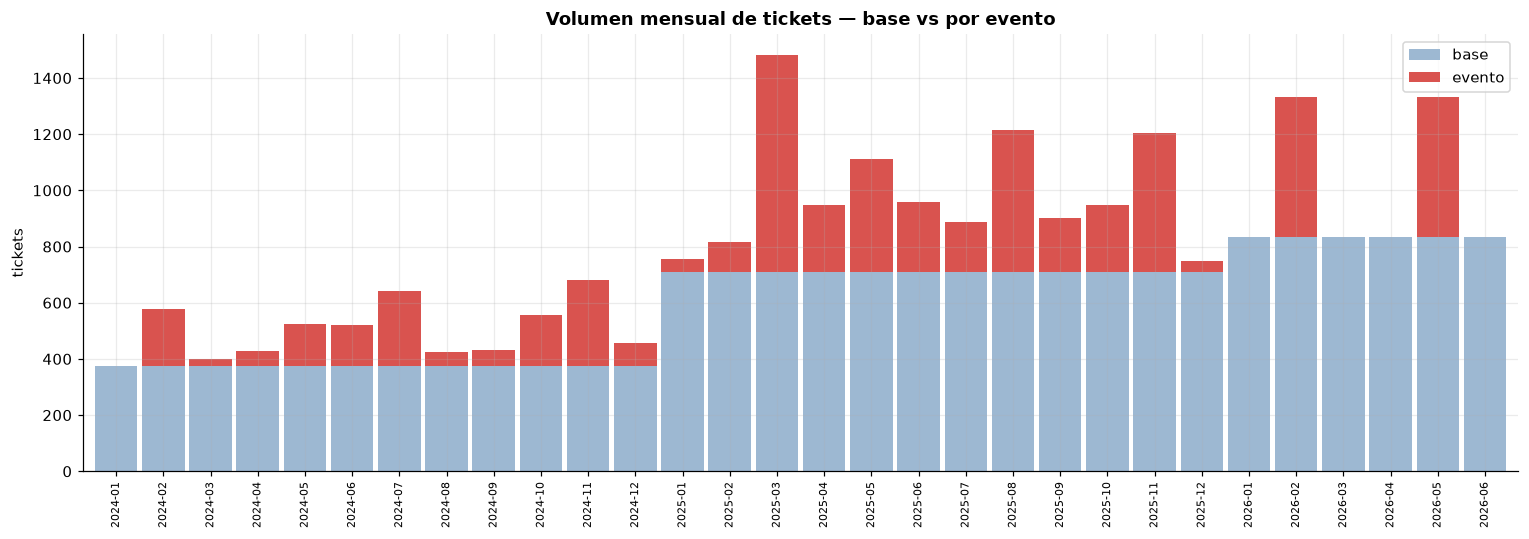

In [6]:
piv = (df.groupby(["month", "is_event"]).size()
         .unstack(fill_value=0).rename(columns={False: "base", True: "evento"}))
# etiquetas de mes como texto: un índice datetime en un bar plot dispara un bug de pandas (Period/freq)
piv.index = piv.index.strftime("%Y-%m")
ax = piv[["base", "evento"]].plot(kind="bar", stacked=True, figsize=(14, 5),
                                  color=[BASE_C, EVT_C], width=0.9)
ax.set_title("Volumen mensual de tickets — base vs por evento", fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("tickets")
ax.tick_params(axis="x", labelrotation=90); ax.tick_params(axis="x", labelsize=7)
ax.legend(title="")
plt.tight_layout(); plt.show()

**Cómo leerlo:** la banda clara (base) crece ~2x de 2024 a 2025 al escalar la
empresa, y sigue hacia 2026-H1. Los picos rojos son **outages** (un conector o los
dashboards se rompen → estallido de tickets en días). Los cúmulos rojos más anchos
son **olas de lanzamiento** (sale un conector nuevo → semanas de preguntas de "cómo
lo conecto"). Ese agrupamiento es lo que muestra una cola real — y lo que un modelo
de pronóstico o de anomalías necesita aprender.

## 2. El arco de lanzamiento — pedidos que desaparecen el día del launch

Antes de que exista un conector, los clientes preguntan *"¿cuándo van a agregar X?"*
(un `feature_request`). En cuanto sale, esos pedidos paran y se vuelven *"¿cómo
conecto X?"* (`how_to`). Graficando los **feature-requests de conectores por mes**
con cada fecha de lanzamiento marcada, se ve la demanda subir y luego caer.

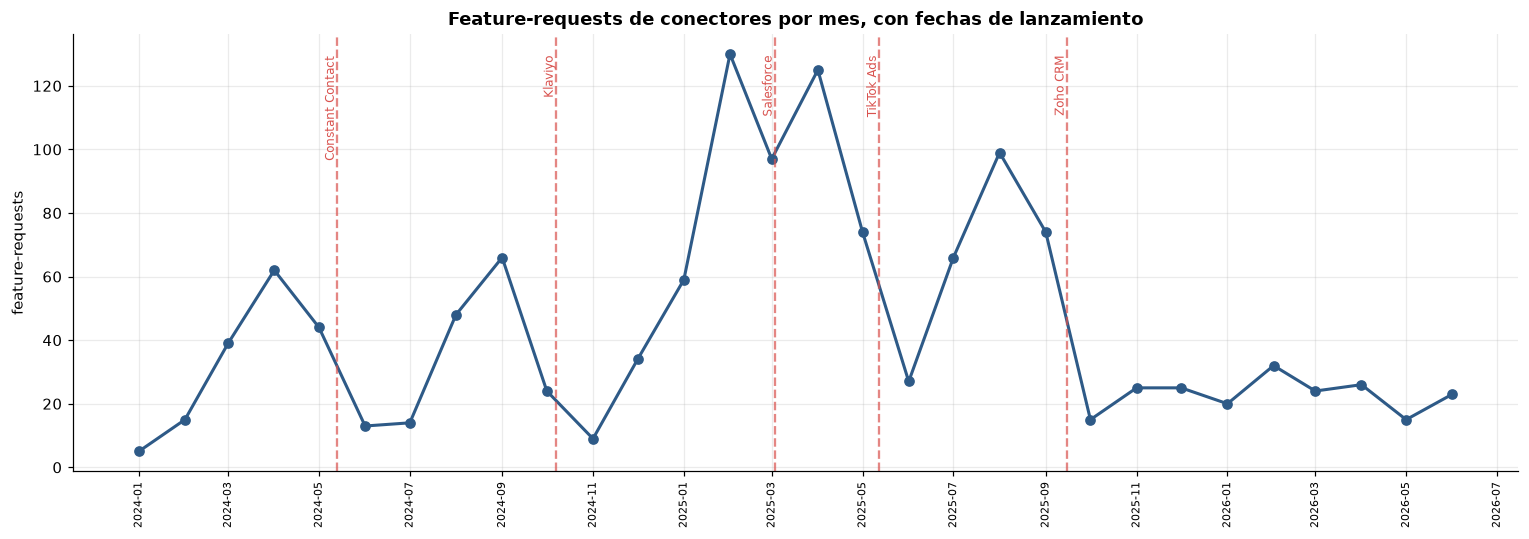

In [7]:
fr = df[(df.type == "feature_request") & (df.topic == "connectors")]
monthly_fr = fr.groupby("month").size()
launches = {"Constant Contact": "2024-05-13", "Klaviyo": "2024-10-07",
            "Salesforce": "2025-03-03", "TikTok Ads": "2025-05-12",
            "Zoho CRM": "2025-09-15"}
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_fr.index, monthly_fr.values, marker="o", color=ACCENT, lw=2)
ax.set_title("Feature-requests de conectores por mes, con fechas de lanzamiento",
             fontweight="bold")
ax.set_ylabel("feature-requests"); ax.set_xlabel("")
for name, d in launches.items():
    ts = pd.Timestamp(d)
    ax.axvline(ts, color=EVT_C, ls="--", alpha=0.7)
    ax.text(ts, ax.get_ylim()[1]*0.95, name, rotation=90, va="top",
            ha="right", fontsize=8, color=EVT_C)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=90, fontsize=7); plt.tight_layout(); plt.show()

**Cómo leerlo (ojo, es al revés de lo que parece):** cada línea punteada es un
conector saliendo a producción. El volumen de *pedidos* **sube acercándose** al
lanzamiento y **cae justo después** — o sea, los picos son la gente *pidiendo* el
conector ANTES de que exista, y la demanda se apaga cuando lo entregas (ya nadie
pide lo que ya está). El pico = "lo quiero", no "ya lo tienen". La línea mezcla todos
los feature-requests de conectores (por eso es un poco ruidosa); la versión nítida de
esta señal es la tabla de antes/después por conector.

## 3. Distribución de etiquetas — los objetivos del modelo (ML)

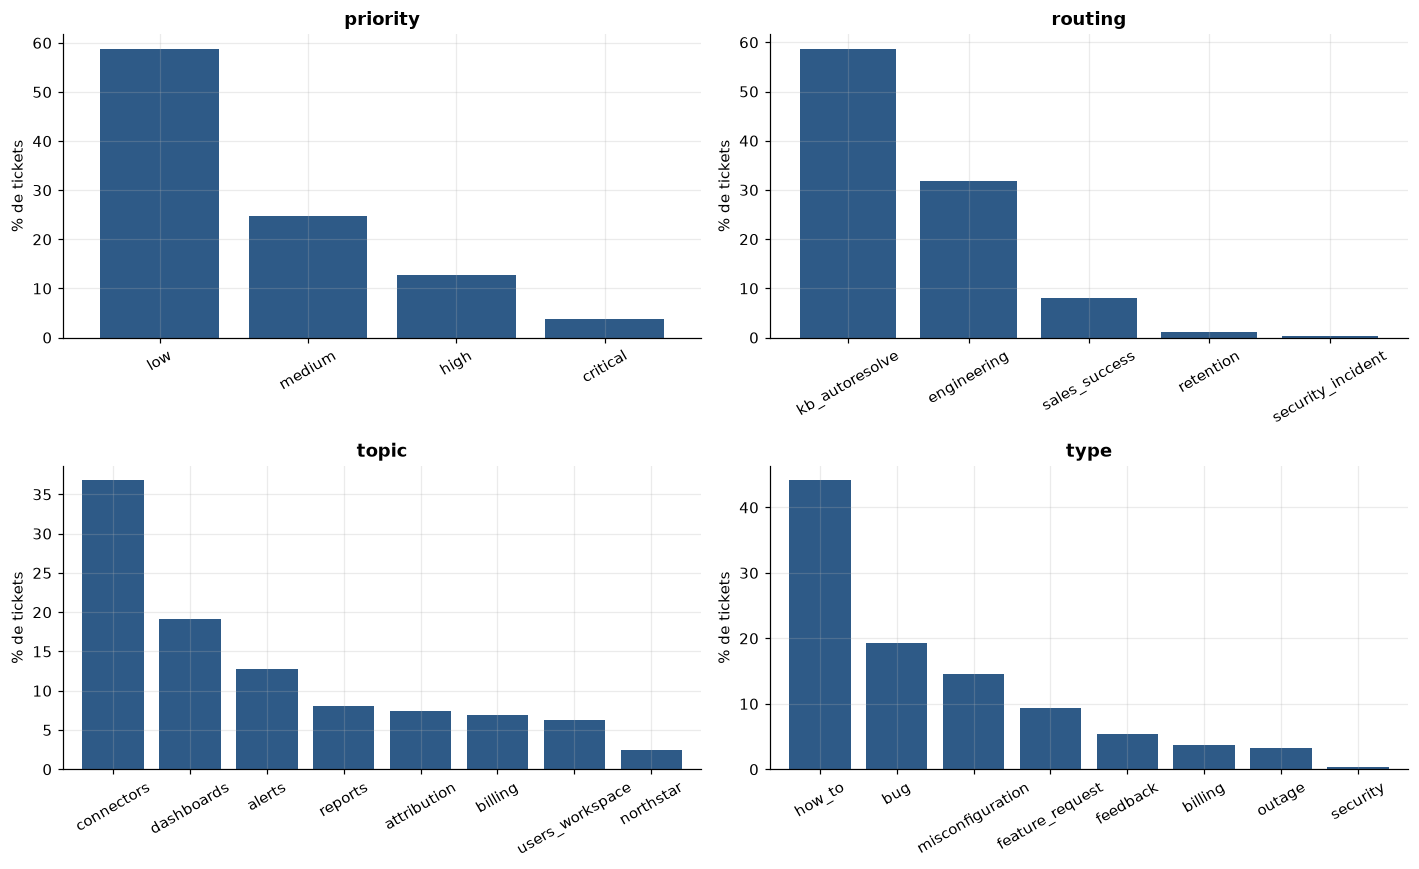

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [("priority", ["low", "medium", "high", "critical"]),
         ("routing", None), ("topic", None), ("type", None)]
for ax, (col, order) in zip(axes.ravel(), specs):
    vc = df[col].value_counts()
    if order:
        vc = vc.reindex(order)
    (vc / len(df) * 100).plot(kind="bar", ax=ax, color=ACCENT, width=0.8)
    ax.set_title(col, fontweight="bold"); ax.set_ylabel("% de tickets")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Cómo leerlo:** **priority** sigue una cola larga realista (casi todo es
rutina, poco es crítico), sesgada un poco hacia high/critical por los outages.
**routing** lo domina `kb_autoresolve` — la oportunidad de deflexión que ataca el
RAG. **topic** y **type** quedan repartidos por todo el producto, así que ninguna
clase domina trivialmente al clasificador.

### Frecuencias exactas — los números detrás de las barras

In [9]:
def freq_table(col, order=None):
    vc = df[col].value_counts()
    if order:
        vc = vc.reindex(order)
    return pd.DataFrame({"conteo": vc, "pct_%": (vc / len(df) * 100).round(1)})

pd.concat({c: freq_table(c) for c in ["topic", "type", "routing"]}, names=["campo", "valor"])

conteo  pct_%
campo   valor                           
topic   connectors           8827   36.8
        dashboards           4600   19.2
        alerts               3065   12.8
        reports              1940    8.1
        attribution          1777    7.4
        billing              1666    6.9
        users_workspace      1515    6.3
        northstar             604    2.5
type    how_to              10591   44.1
        bug                  4644   19.4
        misconfiguration     3498   14.6
        feature_request      2237    9.3
        feedback             1288    5.4
        billing               895    3.7
        outage                764    3.2
        security               77    0.3
routing kb_autoresolve      14089   58.7
        engineering          7645   31.9
        sales_success        1924    8.0
        retention             259    1.1
        security_incident      77    0.3

In [10]:
freq_table("priority", ["low", "medium", "high", "critical"])

,conteo,pct_%
priority,,
low,14116,58.8
medium,5935,24.7
high,3051,12.7
critical,892,3.7


### Cruce: topic × type

Qué *tipos* de ticket aparecen en qué *áreas* del producto — conteos, con totales.

In [11]:
pd.crosstab(df.topic, df.type, margins=True, margins_name="Total")

type,billing,bug,feature_request,feedback,how_to,misconfiguration,outage,security,Total
topic,,,,,,,,,
alerts,0,571,908,0,901,685,0,0,3065
attribution,0,0,0,0,859,918,0,0,1777
billing,895,0,0,0,771,0,0,0,1666
connectors,0,2031,1329,0,4614,853,0,0,8827
dashboards,0,1468,0,1288,1080,0,764,0,4600
northstar,0,51,0,0,553,0,0,0,604
reports,0,523,0,0,890,527,0,0,1940
users_workspace,0,0,0,0,923,515,0,77,1515
Total,895,4644,2237,1288,10591,3498,764,77,23994


### Cruce: routing × priority

In [12]:
ct = pd.crosstab(df.routing, df.priority, margins=True, margins_name="Total")
ct[["low", "medium", "high", "critical", "Total"]]

priority,low,medium,high,critical,Total
routing,,,,,
engineering,2237,2437,2156,815,7645
kb_autoresolve,10591,3498,0,0,14089
retention,0,0,259,0,259
sales_success,1288,0,636,0,1924
security_incident,0,0,0,77,77
Total,14116,5935,3051,892,23994


## 4. Sentiment — señal operativa de priorización

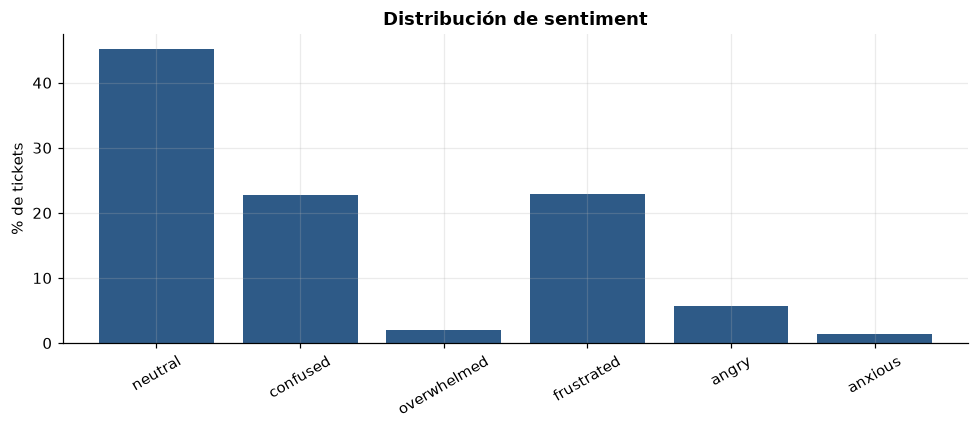

In [13]:
order = ["neutral", "confused", "overwhelmed", "frustrated", "angry", "anxious"]
vc = (df["sentiment"].value_counts().reindex(order) / len(df) * 100)
ax = vc.plot(kind="bar", figsize=(9, 4), color=ACCENT, width=0.8)
ax.set_title("Distribución de sentiment", fontweight="bold")
ax.set_ylabel("% de tickets"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Cómo leerlo:** el sentiment se trata como señal **operativa**, no como verdad
sobre la emoción — alimenta la *priorización* (llegar más rápido al cliente furioso o
ansioso) y la adaptación del tono. Por eso la métrica que importa es el recall en las
emociones que disparan acción, no el accuracy crudo.

## 5. Ruido de intake — por qué el clasificador de triage vale la pena

`reported_category` es la casilla que el propio cliente elige al enviar el ticket —
gruesa y a menudo equivocada. `aligned_category(topic, type)` es la casilla que
*debería* haber elegido si se auto-clasificara bien. La brecha entre las dos es el
margen que un modelo recupera leyendo el texto.

In [14]:
df["aligned"] = [aligned_category(t, ty) for t, ty in zip(df.topic, df.type)]
df["intake_ok"] = df.reported_category == df.aligned
print(f"desajuste de intake global: {(~df.intake_ok).mean()*100:.1f}% de los tickets "
      f"eligen una categoría que NO coincide con las etiquetas reales")

desajuste de intake global: 35.1% de los tickets eligen una categoría que NO coincide con las etiquetas reales


Tasa de desajuste por topic real — dónde más se equivoca el usuario:

In [15]:
g = df.groupby("topic")["intake_ok"]
noise = pd.DataFrame({"n": g.size(), "desajuste_%": ((1 - g.mean()) * 100).round(1)})
noise.sort_values("desajuste_%", ascending=False)

,n,desajuste_%
topic,,
reports,1940,37.8
attribution,1777,36.8
billing,1666,35.8
dashboards,4600,35.6
connectors,8827,34.5
users_workspace,1515,34.1
alerts,3065,33.9
northstar,604,32.8


**Cómo leerlo:** cerca de un tercio de los tickets llega mal categorizado por el
usuario. Un modelo que lee el *texto* y predice el topic/type verdadero convierte ese
intake ruidoso en una señal de ruteo confiable — ese es el valor de negocio concreto,
no el accuracy por sí mismo.

## 6. Impacto de los eventos en la severidad

La mezcla de prioridad **dentro de las ventanas de evento** vs el **flujo base** hace
explícito el efecto de la capa de eventos.

In [16]:
sev = pd.DataFrame({
    "base_%": (df[~df.is_event].priority.value_counts(normalize=True) * 100).round(1),
    "evento_%": (df[df.is_event].priority.value_counts(normalize=True) * 100).round(1),
}).reindex(["low", "medium", "high", "critical"])
sev

,base_%,evento_%
priority,,
low,60.7,53.3
medium,29.5,10.4
high,8.9,24.1
critical,0.9,12.1


**Cómo leerlo:** los tickets por evento se cargan notoriamente hacia
high/critical frente a la base tranquila — el pico de severidad que produce un
incidente real, y la señal en la que se fija un detector de anomalías. Fíjate que la
base sola queda ~60/30/9/1 (el objetivo de diseño); toda la desviación global viene
de los eventos.

## 7. Largo del mensaje

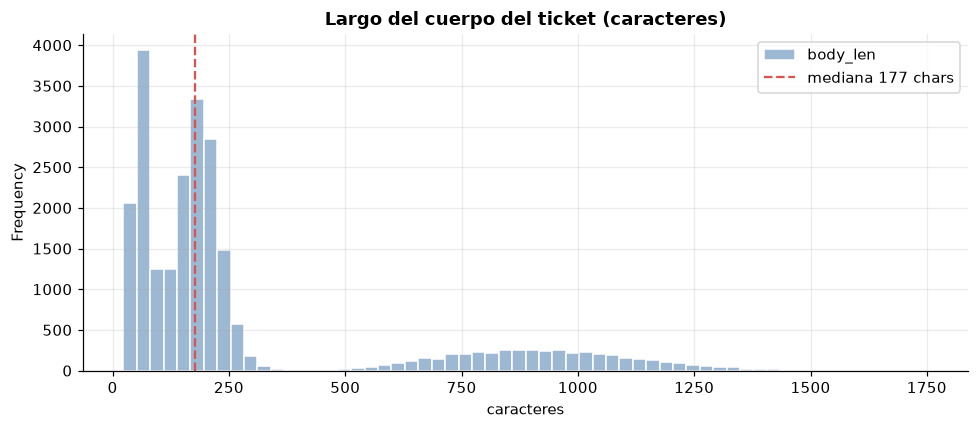

In [17]:
df["body_len"] = df["body"].fillna("").str.len()
ax = df["body_len"].plot(kind="hist", bins=60, figsize=(9, 4), color=BASE_C,
                         edgecolor="white")
ax.axvline(df.body_len.median(), color=EVT_C, ls="--",
           label=f"mediana {int(df.body_len.median())} chars")
ax.set_title("Largo del cuerpo del ticket (caracteres)", fontweight="bold")
ax.set_xlabel("caracteres"); ax.legend()
plt.tight_layout(); plt.show()

**Cómo leerlo:** una distribución sesgada a la derecha — muchos mensajes cortos
de chat, una cola larga de correos detallados — igual que el perfil de largo medido
en datasets públicos reales durante la calibración.

## Qué habilita este dataset

- **Clasificación de triage** — predecir topic / type / priority / routing /
  sentiment desde el texto crudo (etiquetas verdaderas coherentes por construcción).
- **Deflexión con RAG** — la masa `kb_autoresolve` es donde un asistente RAG anclado
  y con rechazo honesto se gana el sueldo.
- **Series de tiempo** — los picos de outage y las olas de lanzamiento hacen
  aprendibles el **pronóstico** de volumen y la **detección de anomalías**, cosa que
  un set sintético plano no soporta.

*Dato sintético, generado con un pipeline real. Sin usuarios reales, sin PII.*